In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (2.5, 2.5)
plt.rc('axes.spines', top=False, right=False)

import seaborn as sns
import scipy

print(mpl.__version__, pd.__version__)

3.10.9 2.3.3


## Summary stats 2: MAF <> Burden

In [2]:
ANNO_ORDER = ['ESM1B','AM','GPN','CADD16','CADD17']

bs = pd.read_parquet('release/ml-burden.sumstats.af.parquet')

pheno_groups = {
    'height': 'Height',
    'weight': 'Anthropometric',
    'bmi': 'Anthropometric',
    'fev1': 'Pulmonary',
    'fvc': 'Pulmonary',
    'fev1_fvc_ratio': 'Pulmonary',
    'iop-R': 'Ocular',
    'iop-L': 'Ocular',
    'iop-G-R': 'Ocular',
    'iop-G-L': 'Ocular',
    'ch-R': 'Ocular',
    'ch-L': 'Ocular',
    'crf-R': 'Ocular',
    'crf-L': 'Ocular'
}

bs = bs.rename(
    {
        'pop_sample': 'Population',
        'af':         'AF',
        'pheno':      'Trait',
        'mask':       'Mask',
    },
    axis = 1
)
bs['Annotation'] = bs['anno'].str.upper().replace({'ESM':'ESM1B'})
bs['Trait category'] = bs['Trait'].apply(pheno_groups.get)

bs.head()

,CHROM,GENPOS,GENE,gene_id,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,Trait,anno,Mask,test_keys,Population,AF,Annotation,Trait category
0,1,925946,SAMD11,ENSG00000187634,0.000040,337286,ADD,0.296299,0.178589,2.752660,1.012810,bmi,am,del,BURDEN,all,singleton,AM,Anthropometric
1,1,925946,SAMD11,ENSG00000187634,0.000184,337286,ADD,0.149906,0.083345,3.235030,1.142190,bmi,am,del,BURDEN,all,1e-05,AM,Anthropometric
2,1,925946,SAMD11,ENSG00000187634,0.000769,337286,ADD,0.023663,0.040765,0.336946,0.250575,bmi,am,del,BURDEN,all,1e-04,AM,Anthropometric
3,1,925946,SAMD11,ENSG00000187634,0.000769,337286,ADD,0.023663,0.040765,0.336946,0.250575,bmi,am,del,BURDEN,all,1e-03,AM,Anthropometric
4,1,925946,SAMD11,ENSG00000187634,0.000769,337286,ADD,0.023663,0.040765,0.336946,0.250575,bmi,am,del,BURDEN,all,1e-02,AM,Anthropometric


### Gene constraint

In [3]:
s_het = pd.read_csv('data/s_het_estimates.genebayes.tsv', sep='\t')
lower_s, upper_s = s_het['post_mean'].quantile([0.25, 0.75])
print(lower_s, upper_s)

s_het_d = dict(s_het[['ensg','post_mean']].values)
for df in [bs]:
    df['s_het'] = df['gene_id'].apply(s_het_d.get)
    df['1/s_het'] = 1./df['s_het']
    df['s_het_high'] = (df['s_het'] > upper_s)
    df['s_het_low']  = (df['s_het'] < lower_s)

0.002305035 0.050771


In [4]:
loeuf = pd.read_csv('data/gnomad.v4.1.constraint_metrics.tsv', sep='\t')
lower_l, upper_l = loeuf['lof.oe_ci.upper'].quantile([0.25, 0.75])
print(lower_l, upper_l)

loeuf_d = dict(loeuf[['gene_id','lof.oe_ci.upper']].values)
for df in [bs]:
    df['loeuf'] = df['gene_id'].apply(loeuf_d.get) 
    df['1/loeuf'] = 1./df['loeuf']
    df['loeuf_high'] = (df['loeuf'] > upper_l)
    df['loeuf_low']  = (df['loeuf'] < lower_l)

0.584 1.227


### Benign inflation

In [5]:
bs_ixs = ['AF','Population','Annotation','Mask','Trait','Trait category']

bs_gbt = bs.groupby(bs_ixs)

bb = pd.DataFrame()

bb[r'$\lambda_{GC}$'] = bs_gbt['CHISQ'].median().divide(
    scipy.stats.chi2(df = 1).isf(0.5)
)

bb['lambda_gc'] = bb[r'$\lambda_{GC}$']

for p_star in [0.01, 0.001, 0.0001]:
    bb['(p < {})'.format(p_star)] = bs_gbt['LOG10P'].agg(
        lambda b: (b > -np.log10(p_star)).sum()
    )

bb.tail()

$\lambda_{GC}$  \
AF        Population Annotation Mask Trait  Trait category                   
singleton unrelated  GPN        mod  bmi    Anthropometric        1.013838   
                                     fev1   Pulmonary             0.997764   
                                     fvc    Pulmonary             1.003280   
                                     height Height                1.005525   
                                     weight Anthropometric        1.022517   

                                                            lambda_gc  \
AF        Population Annotation Mask Trait  Trait category              
singleton unrelated  GPN        mod  bmi    Anthropometric   1.013838   
                                     fev1   Pulmonary        0.997764   
                                     fvc    Pulmonary        1.003280   
                                     height Height           1.005525   
                                     weight Anthropometric   1.022517   

                                                            (p < 0.01)  \
AF        Population Annotation Mask Trait  Trait category               
singleton unrelated  GPN        mod  bmi    Anthropometric         186   
                                     fev1   Pulmonary              174   
                                     fvc    Pulmonary              176   
                                     height Height                 181   
                                     weight Anthropometric         198   

                                                            (p < 0.001)  \
AF        Population Annotation Mask Trait  Trait category                
singleton unrelated  GPN        mod  bmi    Anthropometric           15   
                                     fev1   Pulmonary                18   
                                     fvc    Pulmonary                16   
                                     height Height                   15   
                                     weight Anthropometric           15   

                                                            (p < 0.0001)  
AF        Population Annotation Mask Trait  Trait category                
singleton unrelated  GPN        mod  bmi    Anthropometric             3  
                                     fev1   Pulmonary                  3  
                                     fvc    Pulmonary                  0  
                                     height Height                     1  
                                     weight Anthropometric             1

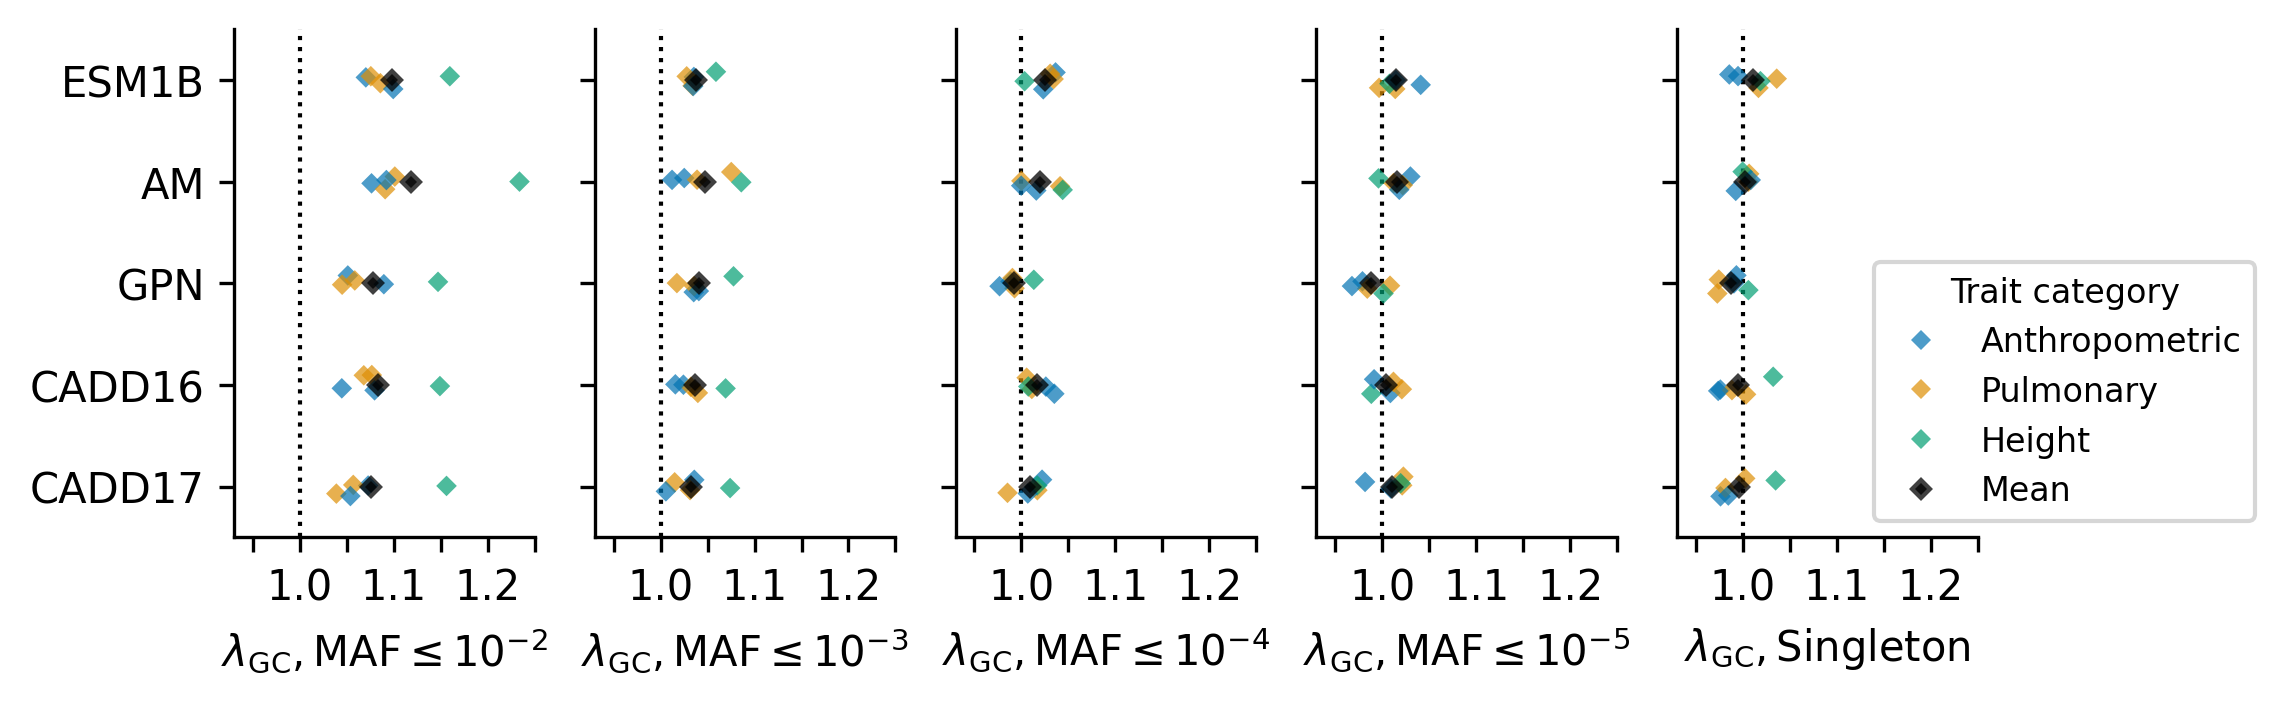

In [6]:
fig, axs = plt.subplots(1, 5, figsize=(7.5, 2.2), dpi=300)

for i, ((af, data), ax) in enumerate(
    zip(
        bb.query(
            'Mask == "ben" & Population == "unrelated"'
        ).groupby('AF'), 
        
        axs.flat)
):   
    # points
    sns.stripplot(
        data = data,
        ax = ax,
        hue = 'Trait category',
        palette = 'colorblind',
        marker = 'D',
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'Annotation',
        s = 3.5,
        alpha = 0.7,
        legend = (i == 4),
        zorder = 5,
    );

    # means
    sns.pointplot(
        data = data,
        ax = ax,
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'Annotation',
        linestyles = '',
        errorbar = None,
        marker = 'D',
        color = 'k',
        ms = 2,
        alpha = 0.75,
        legend = (i == 4),
        label = 'Mean',
        zorder = 6,
    );

        
    ax.axvline(1.0, linestyle='dotted', linewidth=1, color='k');
    ax.set_xlabel(r'$\lambda_\text{GC}, $' + (r'MAF$\leq10^{{ {0:.0f} }}$'.format(round(np.log10(float(af)))) if 'i' not in af else af.capitalize()));
    ax.set_xticks([0.95,1, 1.05, 1.1, 1.15, 1.2, 1.25], labels=['','1.0','','1.1','','1.2','']);
    ax.set_xlim(0.93, 1.25);
    if i != 0:
        ax.set_yticks(list(ax.get_yticks()), labels = ['' for _ in ax.get_yticklabels()]);
    ax.set_ylabel(None);
    if i == 4:
        ax.legend(title='Trait category', title_fontsize=8, frameon=1, fontsize=8, bbox_to_anchor=(0.6, 0.0), loc='lower left');

#fig.tight_layout();
sns.despine();

### W1 distances 

In [7]:
# wasserstein distances
w1 = pd.concat(
    [
        # calibration error
        bs.query('Mask == "ben"').groupby(
            ['Annotation','AF','Population','Trait']
        )['CHISQ'].apply(
            lambda x2: 
            np.mean(np.abs( 
                np.sort(x2) - # faster than scipy.stats.wasserstein_distance  
                np.sort(scipy.stats.chi2(df = 1).ppf(np.arange(len(x2)) / len(x2) + 1/(2*len(x2))))
            ))       
        ).rename('Calibration error'),
        
        # signal separation
        bs.query('Mask == "ben" | Mask == "del"').groupby(
            ['Annotation','AF','Population','Trait']
        ).apply(
            lambda df: scipy.stats.wasserstein_distance(
                np.sort(df.query('Mask == "del" & LOG10P >= 3')['CHISQ']), 
                np.sort(
                    df.loc[
                        df['gene_id'].isin(
                            df.query('Mask == "del" & LOG10P >= 3')['gene_id']
                        ) & (df['Mask'] == "ben")
                    , 
                        'CHISQ'
                    ]
                )
            )
        ).rename('Signal separation')
    ], 
    axis = 1
).reset_index()

w1.tail(3)

/tmp/slurmjob.58068303/ipykernel_2128498/2543775584.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


,Annotation,AF,Population,Trait,Calibration error,Signal separation
697,GPN,singleton,unrelated,iop-l,0.018451,11.000537
698,GPN,singleton,unrelated,iop-r,0.018531,11.713595
699,GPN,singleton,unrelated,weight,0.008956,12.160790


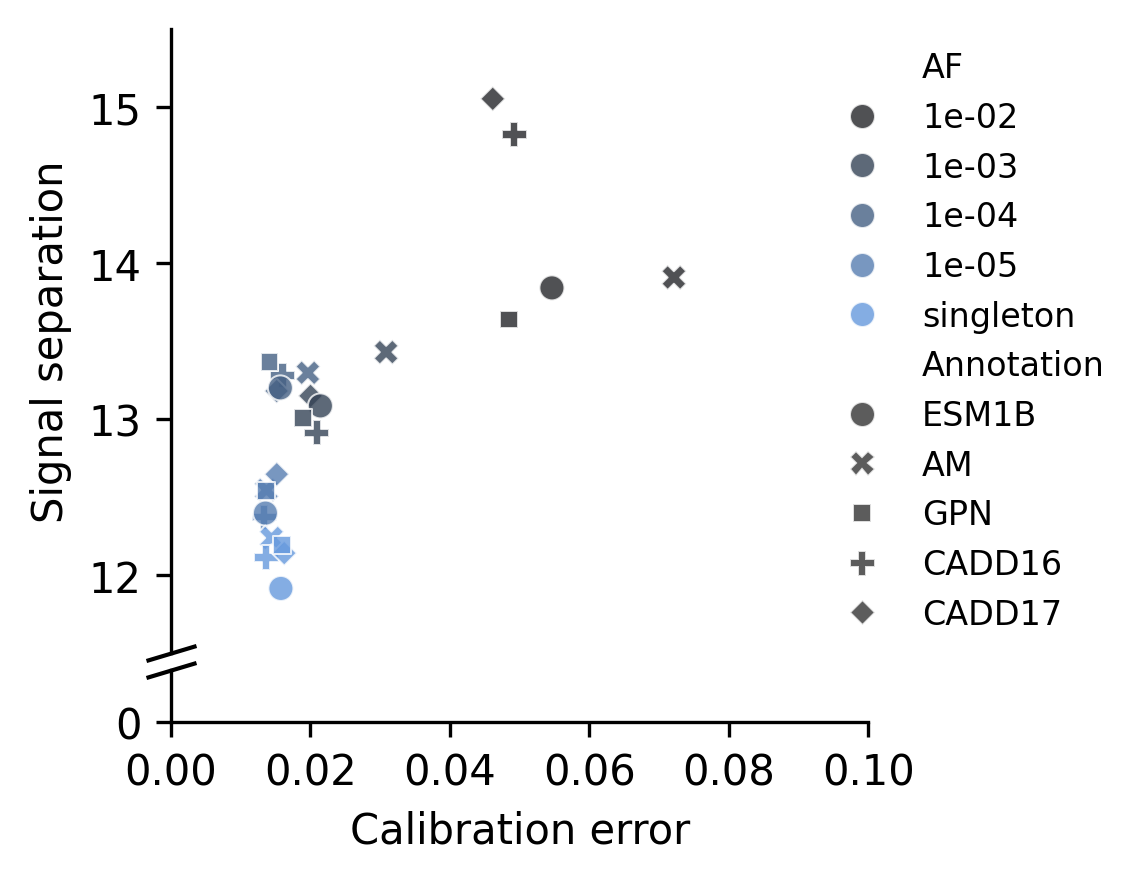

In [8]:
# fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=200)
fig, (ax, ax_break) = plt.subplots(2, 1, figsize=(3,3), sharex=True, gridspec_kw={'height_ratios': [12, 1]})
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

stderr = False

w1_gb = w1.query(
    'Population == "unrelated"'
).groupby(
    ['AF', 'Annotation']
)[['Calibration error','Signal separation']]

means = w1_gb.mean().reset_index()
ses = (w1_gb.std() / w1_gb.count()).reset_index()

if stderr:
    for anno in ['AM','CADD16','GPN','CADD17','ESM']:
        mu, sig = means.query('Annotation == @anno'), ses.query('Annotation == @anno')
        ax.errorbar(
            x = mu['Calibration error'],
            y = mu['Signal separation'],
            xerr = sig['Calibration error'],
            yerr = sig['Signal separation'],
            ms = 0,
            fmt='o', 
            capsize=1, 
            elinewidth=0.8, 
            alpha=0.7
        );

sns.scatterplot(
    ax = ax,
    data = means,
    x = 'Calibration error',
    y = 'Signal separation',
    hue = 'AF',
    palette = "dark:#69d",
    style = 'Annotation',
    style_order = ANNO_ORDER,
    alpha = 0.8,
)

ax.set_xlim(0, 0.1);
ax.set_ylim(11.5, 15.5);

sns.move_legend(ax, loc = 'center left', bbox_to_anchor = (0.9, 0.5), fontsize = 8, frameon = 0);



# hack together the axis break
sns.scatterplot(
    x = 'Calibration error',
    y = 'Signal separation',
    data = means,
    ax = ax_break,
    legend = 0,
); 
ax_break.set_ylim(0, 0.5);
ax_break.set_yticks([0]);
ax_break.set_ylabel(None);
# slanted line 
d = .3  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax.plot([0], [0], transform=ax.transAxes, **kwargs)
ax_break.plot([0], [1], transform=ax_break.transAxes, **kwargs)

sns.despine();
ax.xaxis.set_visible(False)
ax.spines[['bottom']].set_visible(False)
plt.savefig('png/supplement/maf_titration.png', bbox_inches='tight');

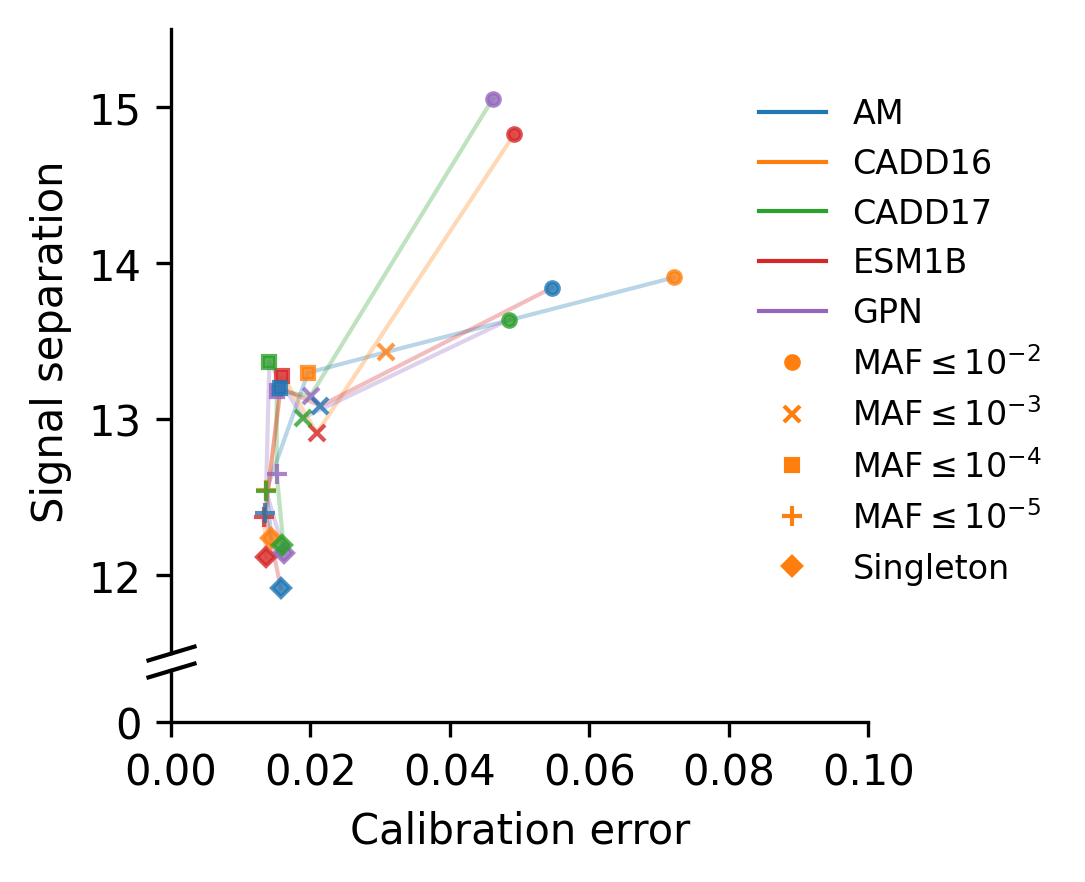

In [9]:
fig, (ax, ax_break) = plt.subplots(2, 1, figsize=(3,3), sharex=True, gridspec_kw={'height_ratios': [12, 1]})
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

w1_gb = w1.query(
    'Population == "unrelated"'
).groupby(
    ['AF', 'Annotation']
)[['Calibration error','Signal separation']]

means = w1_gb.mean().reset_index()
ses = (w1_gb.std() / w1_gb.count()).reset_index()
means = means.sort_values('AF')

for a,a_df in means.groupby('Annotation'):
    ax.plot(
        a_df['Calibration error'],
        a_df['Signal separation'],
        '-',
        alpha = 0.3,
        linewidth = 1,
        label = a,
    );

for ((af,a),afa_df) in means.groupby(['AF','Annotation']):
    ax.plot(
        afa_df['Calibration error'].item(),
        afa_df['Signal separation'].item(),
        linestyle = 'None',
        alpha = 0.8,
        marker = 'oxs+D'[['1e-02','1e-03','1e-04','1e-05','singleton'].index(af)],
        ms = [3,4,3,5,3][['1e-02','1e-03','1e-04','1e-05','singleton'].index(af)],
        color = plt.get_cmap("tab10")(ANNO_ORDER.index(a)),
        label = (r'MAF$\leq10^{{ {0:.0f} }}$'.format(round(np.log10(float(af)))) if '-' in af else af.capitalize()) if a == 'AM' else None,
    );

legend = ax.legend(fontsize=8, frameon=0, loc = 'center left', bbox_to_anchor=(0.8, 0.5)); 
for lh in legend.legend_handles:
    lh.set_alpha(1);

ax_break.set_xlabel('Calibration error');
ax.set_ylabel('Signal separation');

ax.set_xlim(0, 0.1);
ax.set_ylim(11.5, 15.5);


ax_break.set_ylim(0, 0.5);
ax_break.set_yticks([0]);
ax_break.set_ylabel(None);
# slanted line 
d = .3  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax_break.plot([0], [1], transform=ax_break.transAxes, **kwargs)


ax.plot([0], [0], transform=ax.transAxes, **kwargs)
ax.xaxis.set_visible(False)
ax.spines[['bottom']].set_visible(False)

### Validation

#### Constraint

In [10]:
for p_star in [0.01, 0.001, 0.0001]:
    for name, stat in zip([r'$s_\text{het}$', 'LOEUF'], ['s_het', 'loeuf']):
        for hl in ['high','low']:                
            bb['{0} {1} (p < {2})'.format(
                hl, stat, p_star
            )] = bs.query(
                stat+'_'+hl
            ).groupby(
                bs_ixs
            )['LOG10P'].agg(
                lambda b: (b > -np.log10(p_star)).sum()
            )

bb = bb.reset_index()
bb.tail(2)

,AF,Population,Annotation,Mask,Trait,Trait category,$\lambda_{GC}$,lambda_gc,(p < 0.01),(p < 0.001),...,high loeuf (p < 0.01),low loeuf (p < 0.01),high s_het (p < 0.001),low s_het (p < 0.001),high loeuf (p < 0.001),low loeuf (p < 0.001),high s_het (p < 0.0001),low s_het (p < 0.0001),high loeuf (p < 0.0001),low loeuf (p < 0.0001)
748,singleton,unrelated,GPN,mod,height,Height,1.005525,1.005525,181,15,...,48,28,3,3,4,4,0,0,0,0
749,singleton,unrelated,GPN,mod,weight,Anthropometric,1.022517,1.022517,198,15,...,61,24,1,7,7,1,0,1,1,0


In [11]:
bb_gbt = bb.groupby(bs_ixs[:4])

enrich = pd.DataFrame()

for p_star in [0.01, 0.001, 0.0001]:

    enrich['No. of gene-trait pairs (p < {})'.format(p_star)] = bb_gbt['(p < {})'.format(p_star)].sum()
    
    enrich['LoF-Intolerant Enrichment ({0}, {1})'.format(r'$s_{het}$', p_star)] = \
        bb_gbt['high s_het (p < {})'.format(p_star)].sum().divide(
            bb_gbt['low s_het (p < {})'.format(p_star)].sum()
        )
    
    enrich['LoF-Intolerant Enrichment (LOEUF, {})'.format(p_star)] = \
        bb_gbt['low loeuf (p < {})'.format(p_star)].sum().divide(
            bb_gbt['high loeuf (p < {})'.format(p_star)].sum()
        )

enrich['LoF-Intolerant Enrichment ({0})'.format(r'$s_{het}$')] = enrich['LoF-Intolerant Enrichment ({0}, {1})'.format(r'$s_{het}$', p_star)]
enrich['LoF-Intolerant Enrichment (LOEUF)'] = enrich['LoF-Intolerant Enrichment (LOEUF, {})'.format(p_star)]

enrich = enrich.reset_index()
enrich.tail(2)

,AF,Population,Annotation,Mask,No. of gene-trait pairs (p < 0.01),"LoF-Intolerant Enrichment ($s_{het}$, 0.01)","LoF-Intolerant Enrichment (LOEUF, 0.01)",No. of gene-trait pairs (p < 0.001),"LoF-Intolerant Enrichment ($s_{het}$, 0.001)","LoF-Intolerant Enrichment (LOEUF, 0.001)",No. of gene-trait pairs (p < 0.0001),"LoF-Intolerant Enrichment ($s_{het}$, 0.0001)","LoF-Intolerant Enrichment (LOEUF, 0.0001)",LoF-Intolerant Enrichment ($s_{het}$),LoF-Intolerant Enrichment (LOEUF)
148,singleton,unrelated,GPN,del,895,2.072848,0.842795,145,4.923077,1.333333,32,18.0,7.0,18.0,7.0
149,singleton,unrelated,GPN,mod,915,0.825203,0.426471,79,0.500000,0.320000,8,0.0,0.0,0.0,0.0


In [12]:
enrich.query('Population == "unrelated" & Mask == "del"').sort_values('AF').tail(15)

,AF,Population,Annotation,Mask,No. of gene-trait pairs (p < 0.01),"LoF-Intolerant Enrichment ($s_{het}$, 0.01)","LoF-Intolerant Enrichment (LOEUF, 0.01)",No. of gene-trait pairs (p < 0.001),"LoF-Intolerant Enrichment ($s_{het}$, 0.001)","LoF-Intolerant Enrichment (LOEUF, 0.001)",No. of gene-trait pairs (p < 0.0001),"LoF-Intolerant Enrichment ($s_{het}$, 0.0001)","LoF-Intolerant Enrichment (LOEUF, 0.0001)",LoF-Intolerant Enrichment ($s_{het}$),LoF-Intolerant Enrichment (LOEUF)
88,1e-04,unrelated,GPN,del,1295,1.830435,0.726471,237,5.050000,1.166667,77,inf,2.083333,inf,2.083333
85,1e-04,unrelated,ESM1B,del,1341,2.017467,0.814590,268,4.791667,1.428571,87,6.500000,3.222222,6.500000,3.222222
82,1e-04,unrelated,CADD17,del,1362,1.539855,0.617414,254,2.852941,1.291667,84,6.200000,2.083333,6.200000,2.083333
79,1e-04,unrelated,CADD16,del,1417,1.706320,0.682171,260,3.392857,1.294118,74,4.000000,2.090909,4.000000,2.090909
76,1e-04,unrelated,AM,del,1530,2.068702,0.795970,310,2.953488,1.403226,116,7.500000,2.294118,7.500000,2.294118
106,1e-05,unrelated,AM,del,1328,2.485437,0.905660,262,6.789474,1.644444,77,15.666667,3.444444,15.666667,3.444444
109,1e-05,unrelated,CADD16,del,1224,2.201923,0.837134,225,3.814815,1.431818,60,12.500000,2.555556,12.500000,2.555556
112,1e-05,unrelated,CADD17,del,1234,1.871681,0.700000,199,3.833333,1.459459,60,13.000000,3.000000,13.000000,3.000000
115,1e-05,unrelated,ESM1B,del,1165,2.247423,0.881295,220,5.555556,1.818182,66,33.000000,4.166667,33.000000,4.166667
118,1e-05,unrelated,GPN,del,1090,2.198895,0.841509,201,3.958333,1.300000,59,12.333333,3.428571,12.333333,3.428571


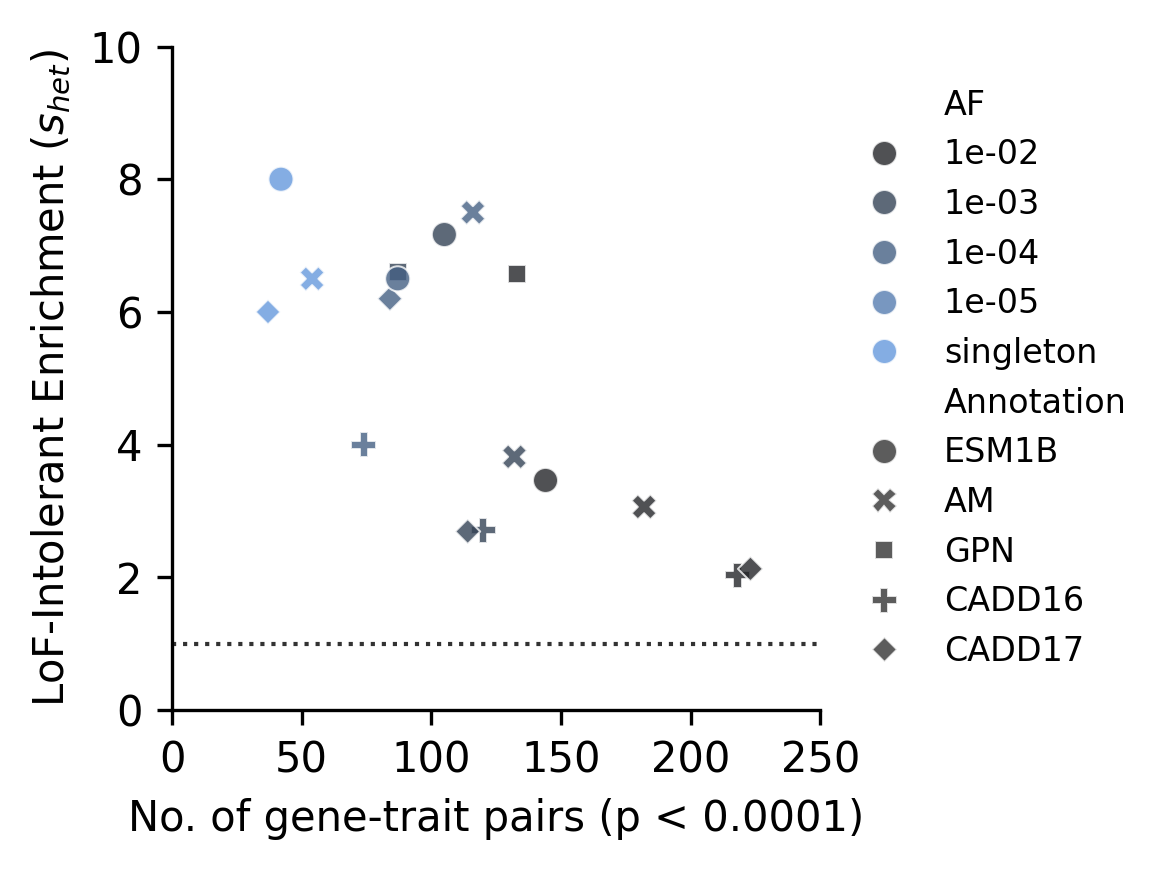

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))

for i,pop in enumerate(['unrelated']):
    sns.scatterplot(
        ax = ax,
        data = enrich.query('(Population == @pop) & (Mask == "bdm" | Mask == "del")'),
        x = 'No. of gene-trait pairs (p < 0.0001)',
        y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$'),
        hue = 'AF',
        palette = "dark:#69d",
        style = 'Annotation',
        style_order = ANNO_ORDER,
        alpha = 0.8,
    )
    ax.set_ylim(0, 10);
    ax.set_xlim(0, 250);
    ax.axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);

sns.move_legend(ax, loc = 'center left', bbox_to_anchor = (1.0, 0.5), fontsize = 8, frameon = 0);
fig.tight_layout()
sns.despine();

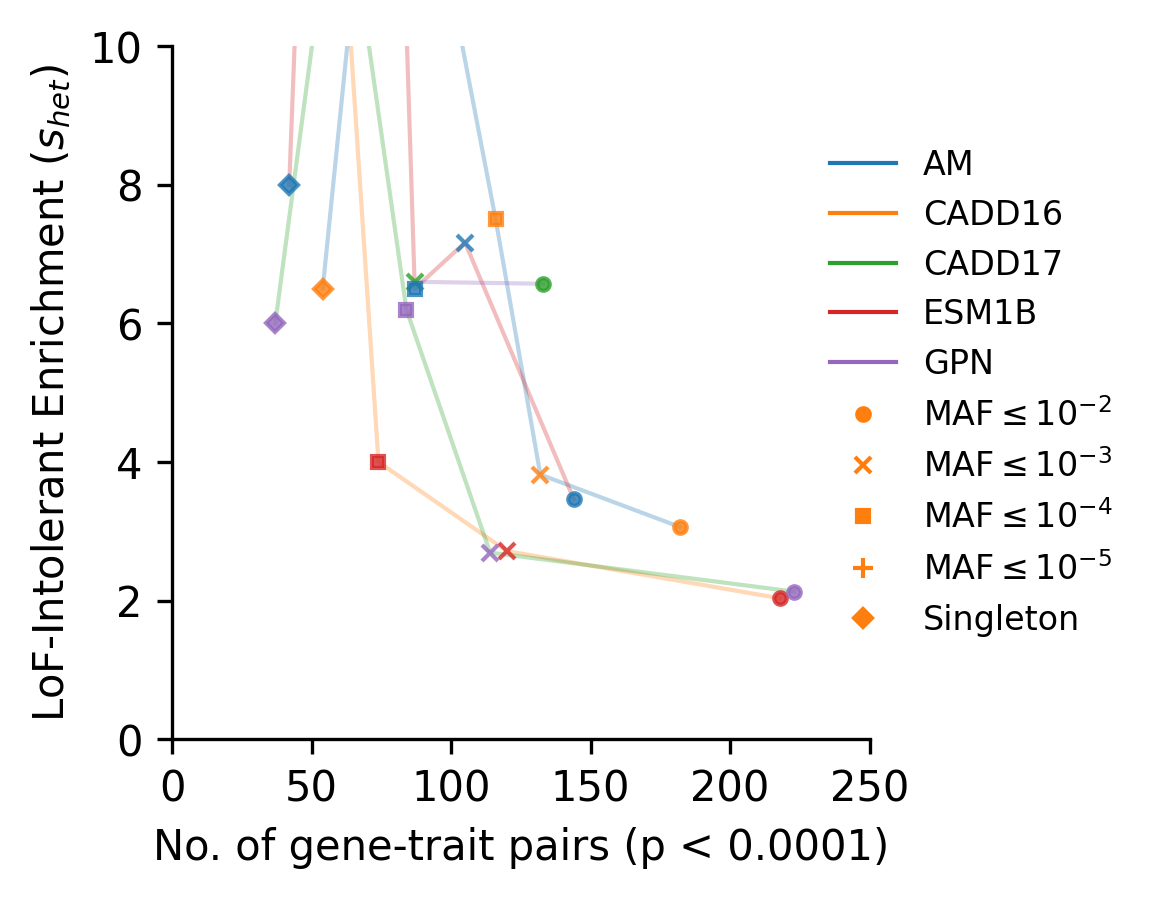

In [14]:
enrich['AF'] = enrich['AF'].replace({'0.01':'1e-02', '0.001':'1e-03', '0.0001':'1e-04'})
enrich = enrich.sort_values('AF')

x = 'No. of gene-trait pairs (p < 0.0001)'
y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$')

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

for a,a_df in enrich.query('Population == "unrelated" & Mask == "del"').groupby('Annotation'):
    ax.plot(
        a_df[x],
        a_df[y],
        '-',
        alpha = 0.3,
        linewidth = 1,
        label = a,
    );

for ((af,a),afa_df) in enrich.query('Population == "unrelated" & Mask == "del"').groupby(['AF','Annotation']):
    ax.plot(
        afa_df[x].item(),
        afa_df[y].item(),
        linestyle = 'None',
        alpha = 0.8,
        marker = 'oxs+D'[['1e-02','1e-03','1e-04','1e-05','singleton'].index(af)],
        ms = [3,4,3,5,3][['1e-02','1e-03','1e-04','1e-05','singleton'].index(af)],
        color = plt.get_cmap("tab10")(ANNO_ORDER.index(a)),
        label = (r'MAF$\leq10^{{ {0:.0f} }}$'.format(round(np.log10(float(af)))) if '-' in af else af.capitalize()) if a == 'AM' else None,
    );

legend = ax.legend(fontsize=8, frameon=0, loc = 'center left', bbox_to_anchor=(0.9, 0.5)); 
for lh in legend.legend_handles:
    lh.set_alpha(1);

ax.set_xlim(000, 250); ax.set_ylim(0, 10);
ax.set_xlabel(x); ax.set_ylabel(y); 

#### Trait pairs

In [15]:
pheno_pairs = {
    ('ch-R','ch-L'): 'Ocular', 
    ('crf-R','crf-L'): 'Ocular',
    ('iop-R','iop-L'): 'Ocular',
    ('iop-G-R','iop-G-L'): 'Ocular',
    #('ch-R','iop-R'): 'Ocular', # handles mislabeling (ch-R/L)
    #('ch-L','iop-L'): 'Ocular', # handles mislabeling (iop-R/L)
    #('crf-R','iop-G-R'): 'Ocular', # handles mislabeling (crf-R/L)
    #('crf-L','iop-G-L'): 'Ocular', # handles mislabeling (iop-G-R/L)
    ('fev1', 'fev1_fvc_ratio'): 'Pulmonary',
    ('fev1_fvc_ratio', 'fvc'): 'Pulmonary',
    ('weight','bmi'): 'Anthropometric',
    ('bmi','height'): 'Anthropometric',
}


# count
hits = bs.query(
    '(Mask == "del" | Mask == "bdm") & LOG10P >= 4 & Population == "unrelated"'
).groupby(
    ['AF','Annotation','Mask','gene_id']
)['Trait'].sum().apply(
    lambda s: sum(a in s and b in s for (a,b) in pheno_pairs.keys())
).reset_index().groupby(
    ['AF','Annotation','Mask']
)['Trait'].sum().rename('total')

# temporary
q = bs.query(
    '(Mask == "del" | Mask == "bdm") & LOG10P >= 4 & Population == "unrelated"'
).groupby(
    ['AF','Annotation','Mask','Trait']
)['gene_id'].agg(set).reset_index()

# iou
ious = pd.concat(
    [
        pd.concat([
            q.loc[(q['Trait'] == l)].drop(
                columns='Trait'
            ).set_index(
                ['AF','Annotation','Mask']
            ).rename(
                columns={'gene_id':l}
            ),
        
            q.loc[(q['Trait'] == r)].drop(
                columns='Trait'
            ).set_index(
                ['AF','Annotation','Mask']
            ).rename(
                columns={'gene_id':r}
            ),
        ], axis=1).apply(
            lambda row: len(row[l] & row[r]) / len(row[l] | row[r]) 
                if type(row[l]) == set and type(row[r]) == set 
            else 0, 
            axis=1
        ).rename(
            ':'.join([r, l])
        ) 
        for (r,l) in pheno_pairs.keys()
    ], axis=1
)
ious['iou'] = ious[[':'.join(k) for k in pheno_pairs.keys()]].mean(axis=1)

traits = pd.concat([hits, ious], axis=1).reset_index()
traits = traits.sort_values('AF')

traits.head()

,AF,Annotation,Mask,total,ch-R:ch-L,crf-R:crf-L,iop-R:iop-L,iop-G-R:iop-G-L,fev1:fev1_fvc_ratio,fev1_fvc_ratio:fvc,weight:bmi,bmi:height,iou
0,1e-02,AM,del,33,NaN,NaN,NaN,NaN,0,0,0.230769,0.000000,0.057692
1,1e-02,CADD16,del,28,NaN,NaN,NaN,NaN,0,0,0.227273,0.006667,0.058485
2,1e-02,CADD17,del,39,NaN,NaN,NaN,NaN,0,0,0.260870,0.006410,0.066820
3,1e-02,ESM1B,del,20,NaN,NaN,NaN,NaN,0,0,0.307692,0.000000,0.076923
4,1e-02,GPN,del,17,NaN,NaN,NaN,NaN,0,0,0.058824,0.000000,0.014706


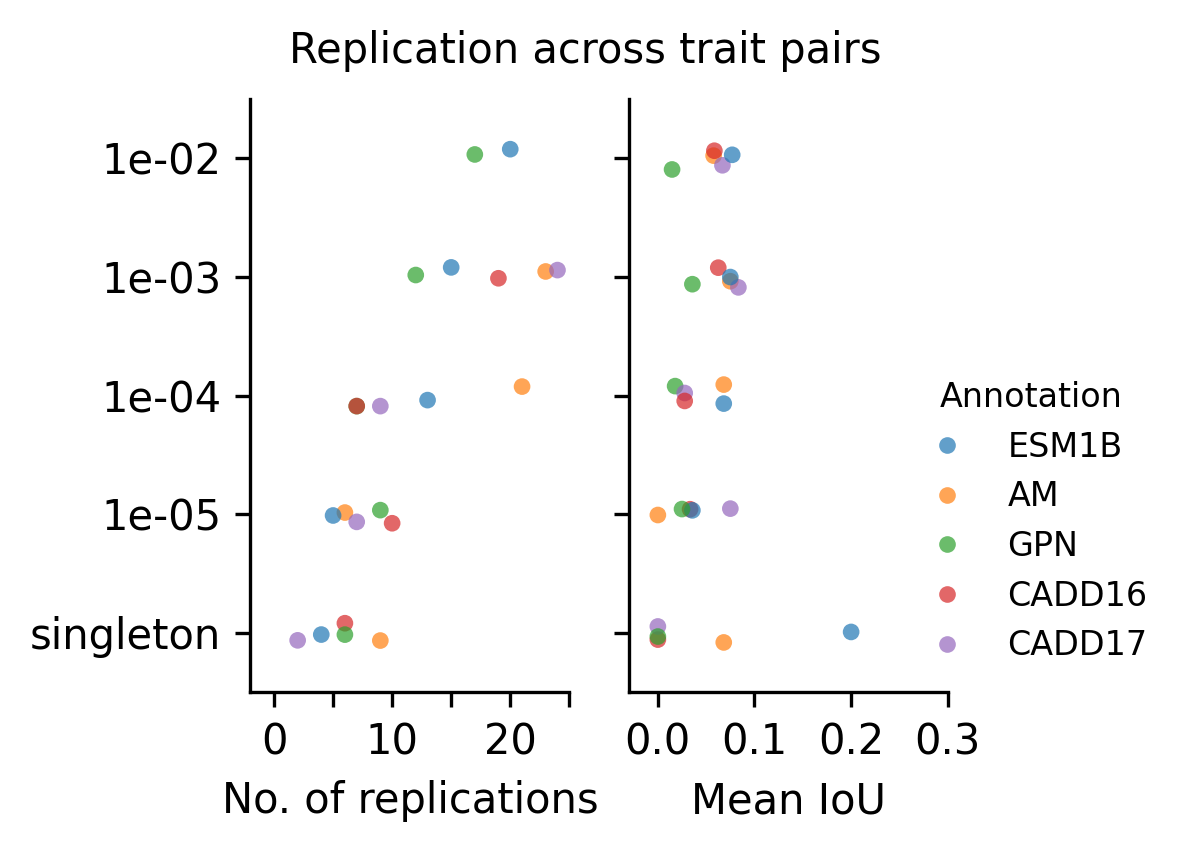

In [16]:
fig, axs = plt.subplots(1, 2, dpi=300, figsize=(4,3))

ax = axs[0]
sns.stripplot(
    data = traits,
    ax = ax,
    x = 'total',
    y = 'AF',
    hue = 'Annotation',
    hue_order = ANNO_ORDER,
    s = 4,
    alpha = 0.7,
    legend = None,
);
ax.set_xlabel('No. of replications');
ax.set_ylabel(None);
ax.set_xlim(-2, 25);
ax.set_xticks([0, 5, 10, 15, 20, 25], labels=['0','','10','','20','']);


ax = axs[1]
sns.stripplot(
    data = traits,
    ax = ax,
    x = 'iou',
    y = 'AF',
    hue = 'Annotation',
    hue_order = ANNO_ORDER,
    s = 4,
    alpha = 0.7,
);
ax.set_xlabel('Mean IoU');
ax.set_ylabel(None);
ax.set_xlim(-0.03, 0.3);
ax.set_xticks([0, 0.1, 0.2, 0.3]);
ax.set_yticks(ax.get_yticks(), labels=['' for _ in ax.get_yticks()]);
ax.legend(frameon=0, title='Annotation', fontsize=8, title_fontsize=8, bbox_to_anchor=(0.8, 0.0), loc='lower left');

fig.suptitle('Replication across trait pairs', fontsize=10, y=0.93);
fig.tight_layout();
sns.despine();

In [18]:
lofs = pd.read_csv('data/genebass_burden_associations_1e-4.tsv.gz', sep='\t')

pheno2code = {
    'bmi': '21001',
    #'ch-L': '5254', # code for iop-R
    'ch-L': '5264', # code for ch-L
    'ch-R': '5256', # code for ch-R (was correct)
    #'crf-L': '5255', # code for iop-G-R
    'crf-L': '5265', # code for crf-L
    'crf-R': '5257', # code for crf-R (was correct)
    'fev1': '3063',
    'fev1_fvc_ratio': '20258',
    'fvc': '3062',
    'height': '50',
    'iop-G-L': '5263', # code for iop-G-L (was correct)
    'iop-G-R': '5255', # code for iop-G-R
    #'iop-G-R': '5265', # code for crf-L
    'iop-L': '5262', # code for iop-L (was correct)
    'iop-R': '5254', # code for iop-R
    #'iop-R': '5264', # code for ch-L 
    'weight': '21002',
}

reps = pd.DataFrame(index = bs.query('(Mask == "del" | Mask == "bdm")')[['Annotation','AF','Mask']].value_counts().index)

s1 = bs.query('(LOG10P >= 4) & (Population == "unrelated") & (Mask == "del" | Mask == "bdm")')

for pheno,code in pheno2code.items():
    if code in lofs['phenocode'].values:
        lof_genebass_genes = lofs.query('phenocode == @code & annotation == "pLoF|missense|LC"')['gene_symbol'].unique()
        print(pheno, len(lof_genebass_genes))
    else:
        continue
    
    s2 = s1.query('(Trait == @pheno)').groupby(['Annotation','AF','Mask'])
    
    reps[pheno + '_overlap_n'] = s2['GENE'].apply(lambda v: v.isin(lof_genebass_genes).sum())
    reps[pheno + '_overlap_rate'] = s2['GENE'].apply(lambda v: v.isin(lof_genebass_genes).sum() / len(v))

reps['total'] = reps.iloc[:,[0,2,4,6,8]].sum(axis=1)
reps['iou'] = reps.iloc[:,[1,3,5,7,9]].mean(axis=1)
reps = reps.reset_index()

reps.iloc[:5,[0,1,2,-2,-1]]

bmi 41
fev1 52
fvc 79
height 359
weight 64


,Annotation,AF,Mask,total,iou
0,CADD16,1e-02,del,133.0,0.549228
1,CADD16,1e-03,del,58.0,0.381709
2,CADD16,1e-04,del,34.0,0.318056
3,CADD17,1e-02,del,132.0,0.558701
4,CADD17,1e-03,del,56.0,0.394886
